#### Buid A Basic ChatBot With LangGraph (Graph API)

In [72]:
## import required libs
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages



In [73]:
class State(TypedDict):
    # Messages have the type "list". The 'add_messages' function
    # in the Annotation defines how this state key should be updated
    # (in this case, it append messages to the list, rather thn over writting them)
    messages:Annotated[list,add_messages]



In [74]:
# import Environment related lib to load KEYS
import os
from dotenv import load_dotenv
# Load Env KEYS and values
load_dotenv()

True

In [75]:
# import generic chat models
from langchain.chat_models import init_chat_model

model = init_chat_model(
    model="qwen/qwen3-32b",
    model_provider="groq"
) # Groq model

In [76]:
# Node functionality
def chatBot(state:State):
    return{"messages":[model.invoke(state["messages"])]}

In [77]:
Graph_Builder = StateGraph(State)
## Add node
Graph_Builder.add_node("groqChatBot",chatBot) 
## Add Edge
Graph_Builder.add_edge(START,"groqChatBot")
Graph_Builder.add_edge("groqChatBot",END)

## Compile the Graph
graph = Graph_Builder.compile()

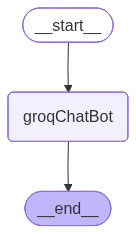

In [78]:
## Visualize Graph
from IPython.display import display,Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [79]:
response = graph.invoke({"messages":"Hi"})

In [80]:
response["messages"][-1].content

'<think>\nOkay, the user said "Hi". That\'s pretty straightforward. I need to respond appropriately. Since it\'s a greeting, the best response is to greet them back and offer help. Let me check if there\'s any specific context I need to consider. The previous messages don\'t show any history, so it\'s a fresh conversation. I should keep it friendly and open-ended.\n\nMaybe something like, "Hello! How can I assist you today?" That covers the greeting and invites them to ask for help. I don\'t want to add too much unless they specify something. Let me make sure the tone is welcoming and not too formal. Yeah, that should work. Alright, time to send the response.\n</think>\n\nHello! How can I assist you today? 😊'

In [81]:
for event in graph.stream({"messages":"Hi how are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

<think>
Okay, the user asked "Hi how are you?" which is a friendly greeting. I need to respond in a warm and approachable manner. Let me start with a cheerful acknowledgment. I should express gratitude for their concern and let them know I'm here to help. Keep it simple and open-ended so they feel comfortable sharing more if they want. Something like "Hi there! Thank you for asking - I'm doing well! How can I assist you today?" That should work.
</think>

Hi there! Thank you for asking - I'm doing well! How can I assist you today? 😊


### ChatBot With Tools

In [82]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the n

In [83]:
## Custom functions
def multiply(a:int,b:int)-> int:
    """Multiply a and b

    Args:
        a (int): First int number
        b (int): Second int number

    Returns:
        int: result in int
    """
    return a*b

def sum(a:int,b:int)-> int:
    """Sum two integer numbers

    Args:
        a (int): First integer number
        b (int): Second Integer Number

    Returns:
        int: Sum of two number
    """
    return a+b

In [84]:
tools=[tool,multiply,sum]

In [85]:
model_with_tools = model.bind_tools(tools)
model_with_tools

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x116563890>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1165d42d0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurat

In [86]:
## StateGraph
from langgraph.graph import StateGraph, START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node Definition
def tool_calling_llm(state:State):
    return{
            "messages":[model_with_tools.invoke(state["messages"])]
           }

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is tool call -> tools_condition routes to tool
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)

builder.add_edge("tools",END)

graph = builder.compile()

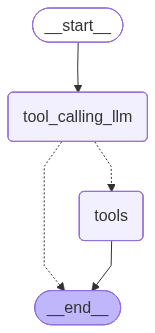

In [87]:
## Visualize Graph
from IPython.display import display,Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [88]:
response = graph.invoke({"messages":"What is recent AI news"})

In [89]:
response['messages'][-1].content

'{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/video/2026/07/10/ais-next-race-cost-control-and-compute.html", "title": "AI’s Next Race: Cost, Control, and Compute - CNBC", "score": 0.6543875, "published_date": "Fri, 10 Jul 2026 21:26:48 GMT", "content": "# AI’s Next Race: Cost, Control, and Compute. Perplexity CEO Aravind Srinivas joins to discuss the company’s new orchestrator model, why he’s building on open-source Chinese AI, and his argument that “token value per watt” may decide the next phase of competition. Then, Benchmark general partner Peter Fenton and Ollama CEO Jeff Morgan discuss the rise of open models, why enterprises are increasingly running models they can download and control, and what Ollama’s growth says about where the AI ecosystem is heading. Apple suing OpenAI over alleged trade secret theft. Imagine Entertainment\'s Brian Grazer: To fear AI would be a big waste of time. Watch CNBC\'s ful

In [90]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is recent AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (w2sg48mr7)
 Call ID: w2sg48mr7
  Args:
    query: AI news
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/video/2026/07/10/ais-next-race-cost-control-and-compute.html", "title": "AI’s Next Race: Cost, Control, and Compute - CNBC", "score": 0.6543875, "published_date": "Fri, 10 Jul 2026 21:26:48 GMT", "content": "# AI’s Next Race: Cost, Control, and Compute. Perplexity CEO Aravind Srinivas joins to discuss the company’s new orchestrator model, why he’s building on open-source Chinese AI, and his argument that “token value per watt” may decide the next phase of compet

In [91]:
response = graph.invoke({"messages":"What is 2 multiplied by 2 ?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiplied by 2 ?
================================== Ai Message ==================================
Tool Calls:
  multiply (0wyxbdjad)
 Call ID: 0wyxbdjad
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: multiply

4


In [92]:
response = graph.invoke({"messages":"What is 2 multiplied by 5 and multiply by 6 ?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiplied by 5 and multiply by 6 ?
================================== Ai Message ==================================
Tool Calls:
  multiply (eq73f6pcm)
 Call ID: eq73f6pcm
  Args:
    a: 2
    b: 5
  multiply (xzeg9145d)
 Call ID: xzeg9145d
  Args:
    a: 10
    b: 6
================================= Tool Message =================================
Name: multiply

10
================================= Tool Message =================================
Name: multiply

60


In [94]:
response = graph.invoke({"messages":"Give me recent AI news and then multiplied 5 by 6 ?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me recent AI news and then multiplied 5 by 6 ?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (xhbz71x8f)
 Call ID: xhbz71x8f
  Args:
    query: recent AI news
    time_range: week
    topic: news
  multiply (3pztgmnks)
 Call ID: 3pztgmnks
  Args:
    a: 5
    b: 6
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.businessinsider.com/new-ai-model-announcements-openai-meta-grok-2026-7", "title": "The Whirlwind 72 Hours of Rival AI Announcements - Business Insider", "score": 0.79958355, "published_date": "Fri, 10 Jul 2026 15:24:46 GMT", "content": "If we're having trouble keeping up with all the AI news this week, we can't imagine how you feel. The last three days have bee

In [ ]:
response = graph.invoke({"messages":"Give me recent AI news and then multiplied 5 by 6 and again multiply by 8 ?"})
for m in response['messages']:
    m.pretty_print()

In [95]:
response = graph.invoke({"messages":"Give me recent AI news and then multiplied 5 by 6 and again multiply by 8 and add with 15?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me recent AI news and then multiplied 5 by 6 and again multiply by 8 and add with 15?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (d4q01bg6j)
 Call ID: d4q01bg6j
  Args:
    query: recent AI news
    time_range: day
    topic: news
  multiply (k61hgtbyp)
 Call ID: k61hgtbyp
  Args:
    a: 5
    b: 6
  multiply (6t9m6vp4q)
 Call ID: 6t9m6vp4q
  Args:
    a: 30
    b: 8
  sum (w6bkxc73z)
 Call ID: w6bkxc73z
  Args:
    a: 240
    b: 15
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.businessinsider.com/new-ai-model-announcements-openai-meta-grok-2026-7", "title": "The Whirlwind 72 Hours of Rival AI Announcements - Business Insider", "score": 0.7923522, "published_date

### REACT Agent Architecture

In [96]:
## StateGraph
from langgraph.graph import StateGraph, START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node Definition
def tool_calling_llm(state:State):
    return{
            "messages":[model_with_tools.invoke(state["messages"])]
           }

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is tool call -> tools_condition routes to tool
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)

builder.add_edge("tools","tool_calling_llm") ## Change END -> with tool_calling_llm

graph = builder.compile()

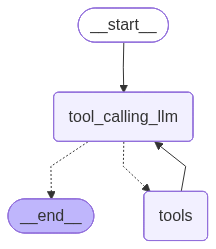

In [97]:
## Visualize Graph
from IPython.display import display,Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [100]:
response = graph.invoke({"messages":"Give me recent AI news and then multiplied 5 by 6 and again multiply by 8 and add with 15?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me recent AI news and then multiplied 5 by 6 and again multiply by 8 and add with 15?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (c7jj1aycn)
 Call ID: c7jj1aycn
  Args:
    query: recent AI news
    search_depth: basic
    time_range: week
  multiply (spx7p6eh8)
 Call ID: spx7p6eh8
  Args:
    a: 5
    b: 6
  multiply (thsre4my5)
 Call ID: thsre4my5
  Args:
    a: 30
    b: 8
  sum (vrn7b5xzm)
 Call ID: vrn7b5xzm
  Args:
    a: 240
    b: 15
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://ai.economictimes.com", "title": "Artificial Intelligence (AI) News Updates: Latest News About ...", "content": "[![Image 5: Image for For one small business, AI was key to a quick sta

### Adding Memory to Agentic Graph

In [101]:
response = graph.invoke({"messages":"Hello My Name is Giresh Singh"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello My Name is Giresh Singh
================================== Ai Message ==================================

Hello Giresh Singh! How can I assist you today?


In [102]:
response = graph.invoke({"messages":"What is my name?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

I don't have access to your personal information, including your name. If you'd like personalized assistance, you can share your name with me, but I won't be able to retrieve it through the available functions.


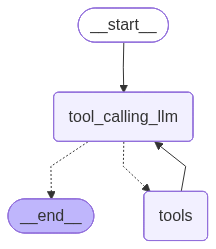

In [103]:
## StateGraph
from langgraph.graph import StateGraph, START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver ## this facilate graph to memorize conversations

## initialize memory saver
memory = MemorySaver()

## Node Definition
def tool_calling_llm(state:State):
    return{
            "messages":[model_with_tools.invoke(state["messages"])]
           }

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is tool call -> tools_condition routes to tool
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)

builder.add_edge("tools","tool_calling_llm") ## Change END -> with tool_calling_llm

graph = builder.compile(checkpointer=memory) ## While compling we will add Memory checkpoin

from IPython.display import display,Image
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [105]:
## Create Config and then give thread id for each conversation to add in memory
config =  {"configurable":{"thread_id":"1"}}
## invoke graph
response = graph.invoke({"messages":"My Name is Giresh Singh"},config=config)
response

{'messages': [HumanMessage(content='My Name is Giresh Singh', additional_kwargs={}, response_metadata={}, id='6bc32228-0b2d-4863-a146-d002c34091e0'),
  AIMessage(content='Hello, Giresh Singh! How can I assist you today?', additional_kwargs={'reasoning_content': "Okay, the user introduced himself as Giresh Singh. Let me see what I need to do here. The tools provided include a search engine and some math functions. But the user isn't asking a question or requesting anything specific. They just provided their name.\n\nHmm, maybe they expect a greeting or a prompt for further assistance. Since there's no direct query, I don't need to call any functions. The search tool isn't necessary here because there's no information to look up. The math functions also aren't relevant unless they ask for calculations.\n\nI should respond politely, acknowledge their name, and offer help if needed. No function calls required here. Just a friendly reply to kick off the conversation.\n"}, response_metadata=

In [106]:
response['messages'][-1].content

'Hello, Giresh Singh! How can I assist you today?'

In [109]:
response = graph.invoke({"messages":"What is My Name ?"},config=config)
print(response['messages'][-1].content)

Your name is Giresh Singh. Let me know if there's anything else I can help with!


In [110]:
response = graph.invoke({"messages":"Do you remember My Name ?"},config=config)
print(response['messages'][-1].content)

Yes, I remember your name is Giresh Singh. How can I assist you further? 😊


### Streaming
 Without streaming:   
   Start.                                                     
   │
Node A
   │
Node B
   │
Node C
   │
Return Final Result

With streaming:
Start
   │
Node A  ───► Update
   │
Node B  ───► Update
   │
Node C  ───► Update
   │
Final Result

##### Main Streaming Methods
 1. graph.stream(), 2. graph.astream()

##### Streaming Modes
1. stream_mode="values", 2. stream_mode="updates", 3. stream_mode="messages", 4. stream_mode="debug"


In [111]:
from langgraph.checkpoint.memory import MemorySaver ## this facilate graph to memorize conversations

## initialize memory saver
memory = MemorySaver()


In [112]:
## Create a node definition
def superbot(state:State):
    return{"messages":[model.invoke(state["messages"])]}

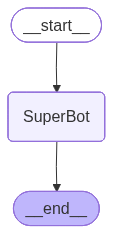

In [114]:
## Create Graph
graph=StateGraph(State)

## Add Node 
graph.add_node("SuperBot",superbot)

## Add Edges
graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)

## Compile Graph
graph_builder = graph.compile(checkpointer=memory)

## Display Graph
from IPython.display import display,Image
display(Image(graph_builder.get_graph().draw_mermaid_png()))


In [115]:
## Invoke Graph
## Create Config and then give thread id for each conversation to add in memory
config =  {"configurable":{"thread_id":"1"}}
## invoke graph
response = graph_builder.invoke({"messages":"My Name is Giresh Singh and I like to play Cricket"},config=config)
response

{'messages': [HumanMessage(content='My Name is Giresh Singh and I like to play Cricket', additional_kwargs={}, response_metadata={}, id='bd4e5f1b-dbc5-430e-b94a-5b3d0cabb191'),
  AIMessage(content="<think>\nOkay, the user introduced themselves as Giresh Singh and mentioned they like to play cricket. I should acknowledge their introduction and express enthusiasm about their interest in cricket. Let me make sure to keep the tone friendly and engaging.\n\nI need to ask them some questions to continue the conversation. Maybe ask about their favorite team, position they play, or any memorable moments in cricket. But first, a proper greeting and a compliment on their name would be nice. Let me check for any possible errors in the response and ensure it's encouraging and open-ended.\n</think>\n\nHello, Giresh Singh! It's lovely to meet you. 🌟 I hope you're having a great day! Cricket is such an amazing sport—I'd love to hear more about what draws you to it. Do you have a favorite team you pla

In [ ]:
## Using Stream with update method
## Create Config and then give thread id for each conversation to add in memory
config =  {"configurable":{"thread_id":"2"}}
## invoke graph
for chunk in graph_builder.stream({"messages":"My Name is Giresh Singh and I like to play Cricket"},config=config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="<think>\nOkay, let's see. The user provided their name, Giresh Singh, and mentioned they like to play cricket. I need to respond appropriately. First, I should acknowledge their introduction. Then, maybe ask a follow-up question to encourage more interaction. Since cricket is their interest, I can ask about their favorite aspect of the game or any specific team they support. I should keep it friendly and open-ended to let them share more. Need to make sure the response is in the same language, which is English here. Also, avoid any markdown formatting as per the instructions. Let me put that together.\n</think>\n\nHello Giresh Singh! It's great to meet you. Cricket is an amazing sport—do you have a favorite part of the game that you enjoy the most, like batting, bowling, or fielding? Also, do you follow any particular team or player? 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 182, 'prompt_tokens': 20, 

In [ ]:
## Using Stream with values method
## Create Config and then give thread id for each conversation to add in memory
config =  {"configurable":{"thread_id":"2"}}
## invoke graph
for chunk in graph_builder.stream({"messages":"My Name is Giresh Singh and I like to play Cricket"},config=config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='My Name is Giresh Singh and I like to play Cricket', additional_kwargs={}, response_metadata={}, id='04fb5237-5a14-4321-8892-0a20b3fb6dfc'), AIMessage(content="<think>\nOkay, let's see. The user provided their name, Giresh Singh, and mentioned they like to play cricket. I need to respond appropriately. First, I should acknowledge their introduction. Then, maybe ask a follow-up question to encourage more interaction. Since cricket is their interest, I can ask about their favorite aspect of the game or any specific team they support. I should keep it friendly and open-ended to let them share more. Need to make sure the response is in the same language, which is English here. Also, avoid any markdown formatting as per the instructions. Let me put that together.\n</think>\n\nHello Giresh Singh! It's great to meet you. Cricket is an amazing sport—do you have a favorite part of the game that you enjoy the most, like batting, bowling, or fielding? Also, do 

In [120]:
## Using Stream with values method
## Create Config and then give thread id for each conversation to add in memory
config =  {"configurable":{"thread_id":"3"}}
## invoke graph
for chunk in graph_builder.stream({"messages":"My Name is Giresh Singh and I like to play Cricket"},config=config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="<think>\nOkay, the user mentioned their name again and their interest in cricket. They probably want to continue the conversation about cricket. Let me see how to respond.\n\nIn the previous message, I greeted them and asked about their experience and what they enjoy. Now they just repeated the same message. Maybe they're testing if I'm paying attention or want to start a new conversation. Since they didn't ask a question or provide new info, I should prompt them further.\n\nI should acknowledge their message again and maybe ask more specific questions to get them talking. Let's ask about their favorite part of cricket—batting, bowling, fielding? Also, maybe if they have a favorite team or player. That could help them elaborate and share more.\n\nNeed to keep the tone friendly and encouraging. Use cricket-related emojis to keep it engaging. Make sure the response is welcoming and open-ended so they feel comfortable to share more.\n</think>\

In [121]:
for chunk in graph_builder.stream({"messages":"My Name is Giresh Singh and I also like to play Football"},config=config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='My Name is Giresh Singh and I like to play Cricket', additional_kwargs={}, response_metadata={}, id='ac3075ce-50a4-4fb2-a5d5-43a2ff0891f3'), AIMessage(content="<think>\nOkay, the user introduced himself as Giresh Singh and mentioned he likes playing cricket. I need to respond appropriately. Let me start by greeting him and acknowledging his interest in cricket.\n\nFirst, I should make sure to use his name to personalize the response. Then, ask him a question to engage him further. Maybe something like how long he's been playing or his position in the game. That shows interest in his experience.\n\nI should keep the tone friendly and encouraging. Maybe add a bit about the fun aspects of cricket to connect with him. Also, check if there's anything specific he wants to discuss related to cricket, like tips, strategies, or maybe he's looking for a team. But since he didn't specify, I'll keep it open-ended.\n\nAvoid any technical jargon unless he's into t

In [123]:
## Using astream method
## Create Config and then give thread id for each conversation to add in memory
config =  {"configurable":{"thread_id":"4"}}
## invoke graph
async for chunk in graph_builder.astream_events({"messages":"My Name is Giresh Singh and I like to play Cricket"},config=config,version="v2"):
    print(chunk)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'My Name is Giresh Singh and I like to play Cricket'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019f5091-f3b7-7a72-bbab-c85e0d8da709', 'metadata': {'thread_id': '4', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='My Name is Giresh Singh and I like to play Cricket', additional_kwargs={}, response_metadata={}, id='011b60b9-7fcc-4b5e-bebc-84ec7ef8affd')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019f5091-f3ba-7a81-8d8c-e36193b221c4', 'metadata': {'thread_id': '4', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:e16e6d7a-0086-8c48-5d5b-dbd3f84dc3b3'}, 'parent_ids': ['019f5091-f3b7-7a72-bbab-c85e0d8da709']}
{'event': 'on_chat_model_start', 'data': {'input': {'mess

### Human In Loop